# Phase 2B: Vehicle Detection

## 1. Setup

In [97]:
from ultralytics import YOLO
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('seaborn-v0_8')
print('Libraries loaded')

Libraries loaded


## 2. Load YOLO Model

Using **YOLOv8n** (nano)

In [98]:
model = YOLO('yolov8n.pt')

VEHICLE_CLASSES = {
    2: 'car',
    3: 'motorcycle',
    5: 'bus',
    7: 'truck'
}

print(f'Model loaded')

Model loaded


## 3. Simple Detection Function

In [99]:
def detect_vehicles(model, image_path, conf=0.15, iou=0.40):
    """
    Improved detection with lower confidence threshold.
    
    Parameters:
    - conf: 0.15 (catches more vehicles)
    - iou: 0.40 (better NMS)
    """
    img = cv2.imread(str(image_path))
    h, w = img.shape[:2]
    
    # Use imgsz=1280 for better small object detection
    results = model(
        img,
        conf=conf,
        iou=iou,
        imgsz=1280, 
        classes=list(VEHICLE_CLASSES.keys()),
        verbose=False,
        agnostic_nms=True
    )
    
    detections = []
    for box in results[0].boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        cls_id = int(box.cls[0])
        confidence = float(box.conf[0])
        
        detections.append({
            'x1': float(x1), 'y1': float(y1),
            'x2': float(x2), 'y2': float(y2),
            'confidence': round(confidence, 3),
            'vehicle_type': VEHICLE_CLASSES[cls_id]
        })
    
    return img, detections

print('Detection function defined')

Detection function defined


## 4. Process Images

In [100]:
# Setup directories
IMAGE_DIR = Path('../data/yolo/images')
OUTPUT_DIR = Path('../data/yolo/outputs')
RESULTS_DIR = Path('../data/yolo/results')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

images = sorted(IMAGE_DIR.glob('*.webp'))
print(f'Found {len(images)} images to process')

Found 3 images to process



Processing: top-down-aerial-view-urban-city-traffic-jam-rush-hour-highway-vehicular-intersection-peak-cars-road-147810896.webp
  Detected: 30 vehicles
  Cars: 19
  Buses: 3
  Trucks: 8
  Coverage: 8.96%
  Congestion: Medium
  Saved: detected_top-down-aerial-view-urban-city-traffic-jam-rush-hour-highway-vehicular-intersection-peak-cars-road-147810896.jpg


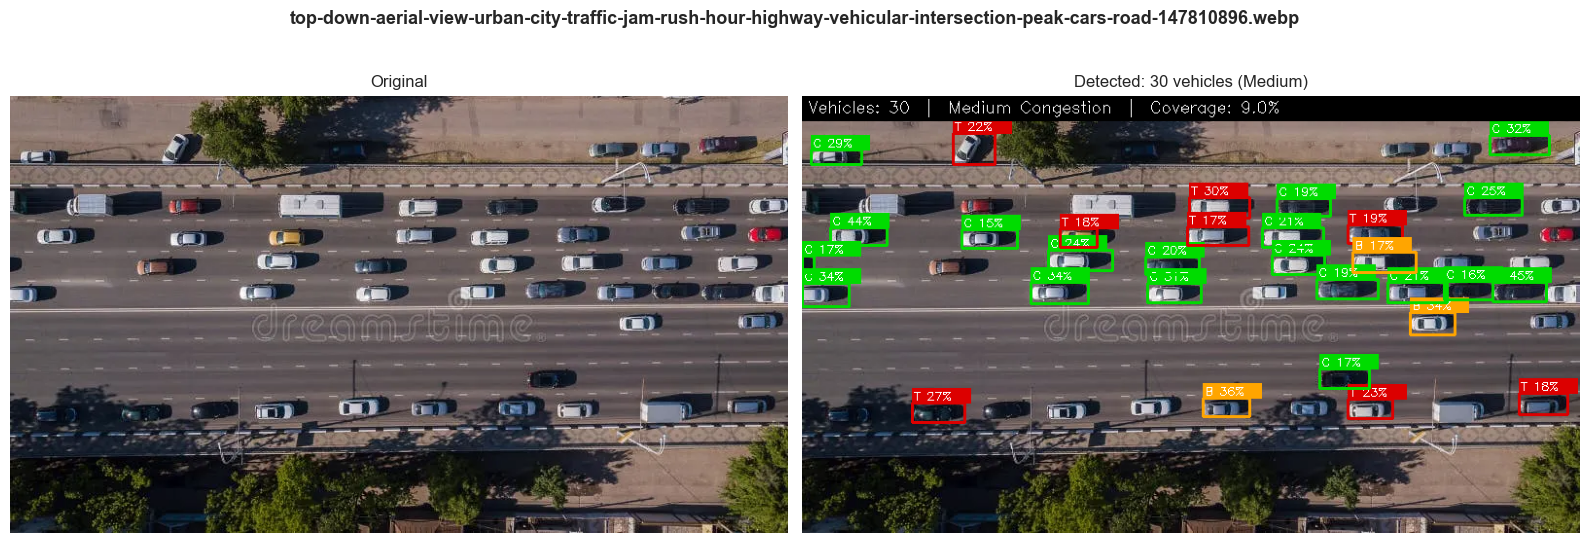


Processing: video_preview_0000 (1).webp
  Detected: 22 vehicles
  Cars: 21
  Buses: 0
  Trucks: 1
  Coverage: 19.11%
  Congestion: High
  Saved: detected_video_preview_0000 (1).jpg


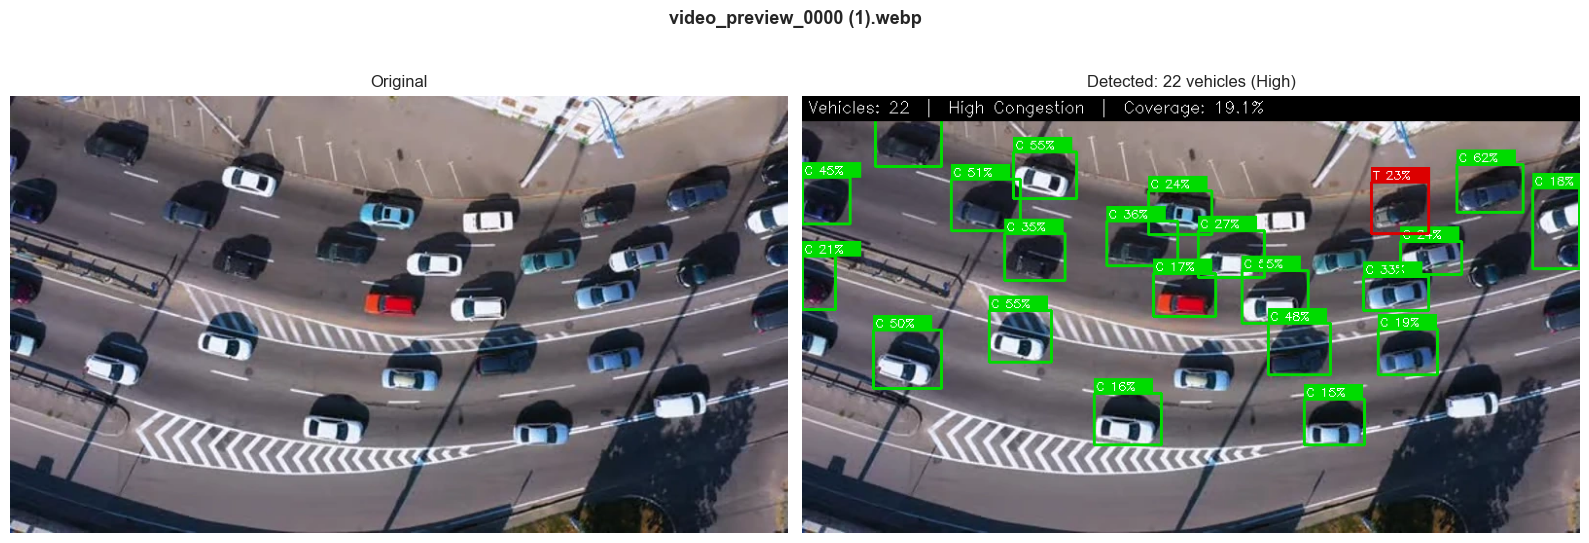


Processing: video_preview_0000.webp
  Detected: 8 vehicles
  Cars: 5
  Buses: 0
  Trucks: 3
  Coverage: 22.62%
  Congestion: Severe
  Saved: detected_video_preview_0000.jpg


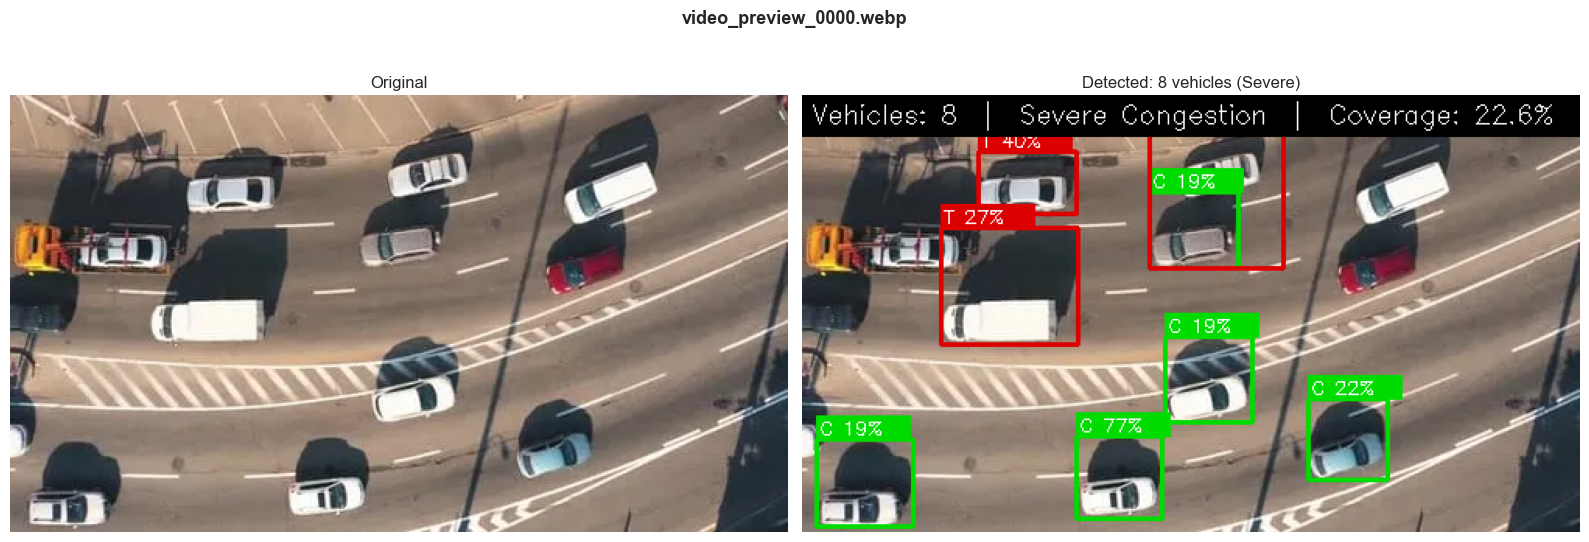

Processed 3 images


In [101]:
# Color map
COLORS = {
    'car': (0, 220, 0),
    'motorcycle': (255, 200, 0),
    'bus': (0, 165, 255),
    'truck': (0, 0, 220)
}

all_results = []

for img_path in images:
    print(f'\n{"="*60}')
    print(f'Processing: {img_path.name}')
    print('='*60)
    
    # Detect
    img, detections = detect_vehicles(model, img_path, conf=0.15)
    h, w = img.shape[:2]
    
    print(f'  Detected: {len(detections)} vehicles')
    
    # Count by type
    type_counts = {}
    for d in detections:
        vtype = d['vehicle_type']
        type_counts[vtype] = type_counts.get(vtype, 0) + 1
    
    print(f'  Cars: {type_counts.get("car", 0)}')
    print(f'  Buses: {type_counts.get("bus", 0)}')
    print(f'  Trucks: {type_counts.get("truck", 0)}')
    
    # Metrics
    total_area = sum((d['x2']-d['x1'])*(d['y2']-d['y1']) for d in detections)
    coverage = (total_area / (w * h)) * 100
    
    if coverage < 4:
        congestion = 'Low'
    elif coverage < 12:
        congestion = 'Medium'
    elif coverage < 22:
        congestion = 'High'
    else:
        congestion = 'Severe'
    
    print(f'  Coverage: {coverage:.2f}%')
    print(f'  Congestion: {congestion}')
    
    # Annotate
    annotated = img.copy()
    for d in detections:
        x1, y1, x2, y2 = int(d['x1']), int(d['y1']), int(d['x2']), int(d['y2'])
        color = COLORS.get(d['vehicle_type'], (0,220,0))
        
        cv2.rectangle(annotated, (x1,y1), (x2,y2), color, 2)
        
        label = f"{d['vehicle_type'][0].upper()} {int(d['confidence']*100)}%"
        cv2.rectangle(annotated, (x1, y1-15), (x1+60, y1), color, -1)
        cv2.putText(annotated, label, (x1+2, y1-3),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)
    
    # Banner
    banner = f"Vehicles: {len(detections)}  |  {congestion} Congestion  |  Coverage: {coverage:.1f}%"
    cv2.rectangle(annotated, (0,0), (w,26), (0,0,0), -1)
    cv2.putText(annotated, banner, (6,18),
               cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255,255,255), 1)
    
    # Save
    output_path = OUTPUT_DIR / f"detected_{img_path.stem}.jpg"
    cv2.imwrite(str(output_path), annotated)
    print(f'  Saved: {output_path.name}')
    
    # Visualize
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    ax1.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax1.set_title('Original', fontsize=12)
    ax1.axis('off')
    
    ax2.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    ax2.set_title(f'Detected: {len(detections)} vehicles ({congestion})', fontsize=12)
    ax2.axis('off')
    
    plt.suptitle(img_path.name, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Store
    all_results.append({
        'image_name': img_path.name,
        'total_vehicles': len(detections),
        'cars': type_counts.get('car', 0),
        'buses': type_counts.get('bus', 0),
        'trucks': type_counts.get('truck', 0),
        'motorcycles': type_counts.get('motorcycle', 0),
        'coverage_ratio': round(coverage, 2),
        'congestion_level': congestion,
        'bounding_boxes': detections
    })

print(f'Processed {len(images)} images')

## 5. Save Results

In [104]:
# Summary CSV
df_summary = pd.DataFrame([{k:v for k,v in r.items() if k != 'bounding_boxes'}
                           for r in all_results])
csv_path = RESULTS_DIR / 'detection_summary.csv'
df_summary.to_csv(csv_path, index=False)
print(f'Saved: {csv_path.name}')
display(df_summary)

# Bounding boxes
bbox_data = []
for result in all_results:
    for bbox in result['bounding_boxes']:
        row = bbox.copy()
        row['image_name'] = result['image_name']
        row['width'] = round(bbox['x2'] - bbox['x1'], 1)
        row['height'] = round(bbox['y2'] - bbox['y1'], 1)
        row['area'] = round(row['width'] * row['height'], 1)
        bbox_data.append(row)

df_boxes = pd.DataFrame(bbox_data)
boxes_path = RESULTS_DIR / 'bounding_boxes.csv'
df_boxes.to_csv(boxes_path, index=False)
print(f'Saved: {boxes_path.name} ({len(df_boxes)} boxes)')

Saved: detection_summary.csv


,image_name,total_vehicles,cars,buses,trucks,motorcycles,coverage_ratio,congestion_level
0,top-down-aerial-view-urban-city-traffic-jam-ru...,30,19,3,8,0,8.96,Medium
1,video_preview_0000 (1).webp,22,21,0,1,0,19.11,High
2,video_preview_0000.webp,8,5,0,3,0,22.62,Severe


Saved: bounding_boxes.csv (60 boxes)


## 6. Visualizations

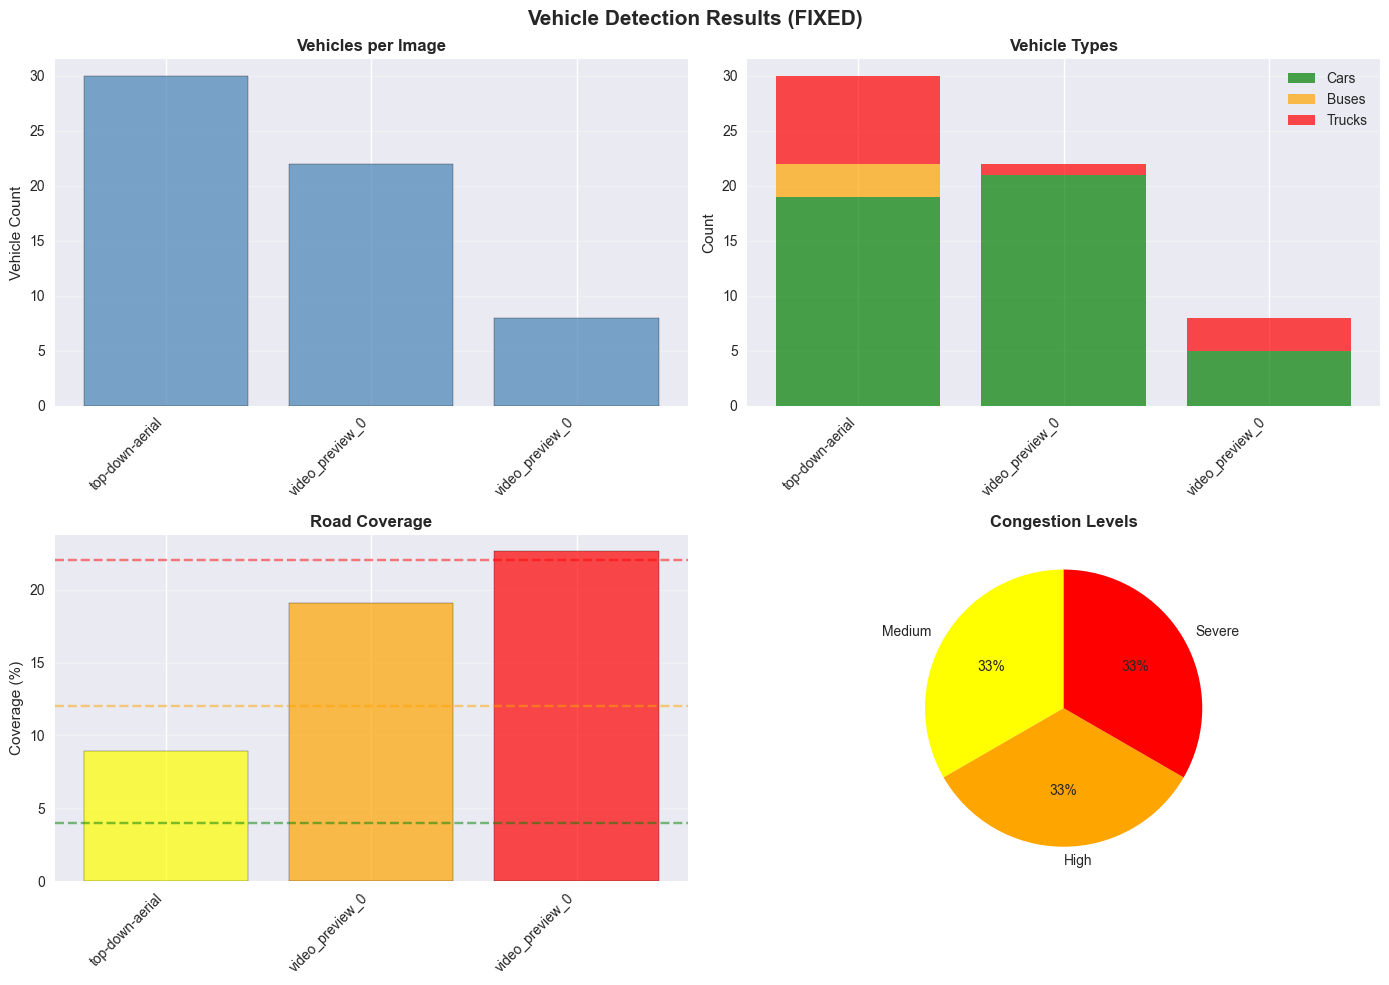

In [103]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Vehicle counts
ax1 = axes[0,0]
x = range(len(df_summary))
ax1.bar(x, df_summary['total_vehicles'], color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_xticks(x)
ax1.set_xticklabels([n[:15] for n in df_summary['image_name']], rotation=45, ha='right')
ax1.set_ylabel('Vehicle Count')
ax1.set_title('Vehicles per Image', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Stacked types
ax2 = axes[0,1]
bottom = np.zeros(len(df_summary))
for vtype, color in [('cars', 'green'), ('buses', 'orange'), ('trucks', 'red')]:
    values = df_summary[vtype].values
    ax2.bar(x, values, bottom=bottom, label=vtype.capitalize(),
           color=color, alpha=0.7)
    bottom += values
ax2.set_xticks(x)
ax2.set_xticklabels([n[:15] for n in df_summary['image_name']], rotation=45, ha='right')
ax2.set_ylabel('Count')
ax2.set_title('Vehicle Types', fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Coverage
ax3 = axes[1,0]
colors_cov = ['green' if c < 4 else 'yellow' if c < 12 else 'orange' if c < 22 else 'red'
             for c in df_summary['coverage_ratio']]
ax3.bar(x, df_summary['coverage_ratio'], color=colors_cov, edgecolor='black', alpha=0.7)
ax3.axhline(4, color='green', linestyle='--', alpha=0.5)
ax3.axhline(12, color='orange', linestyle='--', alpha=0.5)
ax3.axhline(22, color='red', linestyle='--', alpha=0.5)
ax3.set_xticks(x)
ax3.set_xticklabels([n[:15] for n in df_summary['image_name']], rotation=45, ha='right')
ax3.set_ylabel('Coverage (%)')
ax3.set_title('Road Coverage', fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# Congestion pie
ax4 = axes[1,1]
cong_counts = df_summary['congestion_level'].value_counts()
colors_pie = {'Low': 'green', 'Medium': 'yellow', 'High': 'orange', 'Severe': 'red'}
pie_colors = [colors_pie.get(c, 'gray') for c in cong_counts.index]
ax4.pie(cong_counts.values, labels=cong_counts.index, autopct='%1.0f%%',
       colors=pie_colors, startangle=90)
ax4.set_title('Congestion Levels', fontweight='bold')

plt.suptitle('Vehicle Detection Results (FIXED)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()